In [ ]:
%pip install git+https://github.com/Mishne-Lab/pyRATS
# if not already installed on the system:
# %pip install pandas imageio seaborn matplotlib

In [ ]:
from matplotlib import pyplot as plt

from pyRATS import rats, global_distortion
import datasets, vis

import time

matplotlib.get_backend() =  module://matplotlib_inline.backend_inline


# Load data

In [2]:
X, labels, _ = datasets.Datasets().kleinbottle4d(n=5000)

X.shape =  (5000, 4)


# Generate embeddings

In [ ]:
model = rats.RATS(
    n_components=2,
    n_neighbors=28,
    min_cluster_size=5,
    tear=True,
)

start = time.time()

y = model.fit_transform(X=X)

end = time.time()
y, f'runtime: {end - start}'

(array([[ 0.06195062,  0.34341764],
        [ 0.39920025, -0.83283162],
        [ 0.36162704, -0.33783926],
        ...,
        [-0.2008879 ,  0.24726318],
        [ 0.30293562, -0.63351063],
        [ 0.04973587, -0.25065877]], shape=(5000, 2)),
 'runtime: 23.45644998550415')

In [ ]:
n_nbrs = global_distortion.get_n_nbrs_for_distortion_analysis(X)

distortions, max_distortion = global_distortion.compute_global_distortion(
    X,
    y,
    n_nbrs,
    model,
    metric="euclidean",
    max_crossings=20,
)

distortions, max_distortion

(array([1.38568128, 1.31677773, 1.42524444, ..., 1.35330516, 1.41774225,
        1.3398819 ], shape=(5000,)),
 np.float64(13.861955620191477))

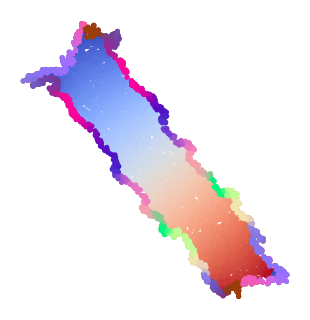

In [5]:
tear_color_eig_inds = [7, 2, 4]
color_of_pts_on_tear = model.compute_color_of_pts_on_tear(
    y,
    tear_color_eig_inds, 
)
vis.Visualize().global_embedding(
    y, labels[:,0],
    color_of_pts_on_tear=color_of_pts_on_tear[:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='coolwarm',
    title='color='+str(tear_color_eig_inds),
    figsize=(3, 3)
)
plt.show()